**LangGraph** lets you define an agent's control flow explicitly as a graph of nodes and edges,
rather than leaving every decision to the model.

[`neo4j-graphrag`](https://neo4j.com/docs/neo4j-graphrag-python/current/) is Neo4j's official
retrieval library. It provides **retrievers** that turn a question into results from your graph
using vector search, full-text search, graph traversal, or a combination.

In this notebook, you'll build a **routed retrieval graph**: a node classifies the question, a
conditional edge sends it to the retriever best suited to it, and a grading node decides whether the
retrieved context is good enough to answer from - or whether to fall back to a broader search.

This is the contrast with tool-calling. An agent *picks* a retriever from a docstring; a LangGraph
node *routes* to one, and the grading step runs whether the model thinks it needs to or not.

In [1]:
!pip install --quiet --upgrade langgraph langchain-openai neo4j-graphrag neo4j openai


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import json
import math
import os
from getpass import getpass
from typing import Literal

import neo4j
from neo4j import GraphDatabase
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from IPython.display import Image, display

from neo4j_graphrag.embeddings import OpenAIEmbeddings
from neo4j_graphrag.retrievers import (
    VectorRetriever,
    HybridRetriever,
    HybridCypherRetriever,
)
from neo4j_graphrag.types import RetrieverResultItem

from langchain.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph

We'll use OpenAI as the LLM provider, specifically GPT-5.4-mini. The same API key covers the embeddings.

In [3]:
os.environ["OPENAI_API_KEY"] = getpass("OpenAI API key")

model = ChatOpenAI(model="gpt-5.4-mini")

## The graph

We'll use the companies database from the Neo4j demo server. Articles are split into `Chunk` nodes
carrying the text and its embeddings, and linked to the organizations they mention:

```
(Article)-[:HAS_CHUNK]->(Chunk)
(Article)-[:MENTIONS]->(Organization)
(Organization)-[:HAS_COMPETITOR|HAS_INVESTOR|HAS_SUPPLIER]->(Organization)
```

That shape is what makes graph retrieval worthwhile. A vector search finds a *chunk* - the article
it belongs to, its date, and the companies it discusses are all one hop away.

In [4]:
NEO4J_URI = "neo4j+s://demo.neo4jlabs.com"
NEO4J_DATABASE = "companies"
NEO4J_USERNAME = "companies"
NEO4J_PASSWORD = "companies"

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
print("Connected to", NEO4J_DATABASE)

Connected to companies


### Cypher version

`neo4j-graphrag` generates its vector searches using the Cypher 25 `SEARCH` clause. The demo database
understands Cypher 25 but still defaults to Cypher 5, so we prefix the generated queries to select the
newer language version. Skip this cell if your own database already defaults to Cypher 25.

In [5]:
if not getattr(neo4j.Driver.execute_query, "_cypher25_patch", False):
    _execute_query = neo4j.Driver.execute_query

    def _execute_query_cypher25(self, query, *args, **kwargs):
        if isinstance(query, str) and "VECTOR INDEX" in query.upper() \
                and not query.lstrip().upper().startswith("CYPHER"):
            query = "CYPHER 25 " + query
        return _execute_query(self, query, *args, **kwargs)

    _execute_query_cypher25._cypher25_patch = True
    neo4j.Driver.execute_query = _execute_query_cypher25

print("Generated vector queries will run as Cypher 25.")

Generated vector queries will run as Cypher 25.


## Pair the embedding model with the index

A vector index stores embeddings produced by one specific model. Query it with a different model and
you still get results - they're just noise, because the two models place the same text at different
points in space. Nothing raises an exception when this happens.

We'll use **`news`**, whose 1536 dimensions correspond to OpenAI's `text-embedding-ada-002`, the
default for `neo4j-graphrag`'s `OpenAIEmbeddings`. **`news_fulltext`** indexes `text` on the same
`Chunk` nodes, which is what makes hybrid retrieval possible.

To confirm the pairing, re-embed a chunk that already has a stored vector and compare. An exact match
scores close to 1.0.

In [6]:
VECTOR_INDEX = "news"
FULLTEXT_INDEX = "news_fulltext"

embedder = OpenAIEmbeddings()


def cosine(a, b):
    dot = sum(x * y for x, y in zip(a, b))
    return dot / (math.sqrt(sum(x * x for x in a)) * math.sqrt(sum(y * y for y in b)))


sample, _, _ = driver.execute_query(
    "MATCH (c:Chunk) WHERE c.embedding IS NOT NULL "
    "RETURN c.text AS text, c.embedding AS stored LIMIT 1",
    database_=NEO4J_DATABASE,
)

score = cosine(embedder.embed_query(sample[0]["text"]), sample[0]["stored"])
print(f"Self-similarity: {score:.3f}",
      "- models match" if score > 0.95 else "- MISMATCH, pick a different index or embedder")

Self-similarity: 1.000 - models match


## Three retrievers

Each has a different strength, which is what makes routing between them worth doing.

- **`VectorRetriever`** - pure semantic search. Good for themes and open-ended questions.
- **`HybridRetriever`** - vector plus full-text, merged. Recovers exact matches on company names and
  tickers that embeddings miss.
- **`HybridCypherRetriever`** - hybrid search followed by a `retrieval_query` that traverses outward
  from each match. Two variables are in scope for that query: `node`, the node the search found, and
  `score`. From there you can walk anywhere in the graph.

The `retrieval_query` is what separates GraphRAG from RAG. Below it collects the source article, its
date and sentiment, the companies mentioned, and their competitors - so retrieved text arrives with
facts the article body never states.

In [7]:
RETRIEVAL_QUERY = """
WITH node AS chunk, score
MATCH (article:Article)-[:HAS_CHUNK]->(chunk)
OPTIONAL MATCH (article)-[:MENTIONS]->(org:Organization)
OPTIONAL MATCH (org)-[:HAS_COMPETITOR]->(rival:Organization)
RETURN chunk.text             AS text,
       article.id             AS article_id,
       article.title          AS title,
       toString(article.date) AS date,
       article.sentiment      AS sentiment,
       collect(DISTINCT org.name)[..5]   AS companies,
       collect(DISTINCT rival.name)[..5] AS competitors,
       score
ORDER BY score DESC
"""


def format_record(record) -> RetrieverResultItem:
    """Shape each result into compact JSON for the model."""
    return RetrieverResultItem(
        content=json.dumps({
            "text": (record.get("text") or "")[:600],
            "article_id": record.get("article_id"),
            "title": record.get("title"),
            "date": record.get("date"),
            "sentiment": record.get("sentiment"),
            "companies": record.get("companies"),
            "competitors": record.get("competitors"),
        }, default=str),
        metadata={"score": record.get("score")},
    )


vector_retriever = VectorRetriever(
    driver=driver, index_name=VECTOR_INDEX, embedder=embedder,
    return_properties=["text"], neo4j_database=NEO4J_DATABASE,
)

hybrid_retriever = HybridRetriever(
    driver=driver, vector_index_name=VECTOR_INDEX, fulltext_index_name=FULLTEXT_INDEX,
    embedder=embedder, return_properties=["text"], neo4j_database=NEO4J_DATABASE,
)

graph_retriever = HybridCypherRetriever(
    driver=driver, vector_index_name=VECTOR_INDEX, fulltext_index_name=FULLTEXT_INDEX,
    retrieval_query=RETRIEVAL_QUERY, embedder=embedder,
    result_formatter=format_record, neo4j_database=NEO4J_DATABASE,
)

# A quick look at what the graph retriever adds over plain vector search.
item = graph_retriever.search(query_text="renewable energy investment", top_k=1).items[0]
print(json.dumps(json.loads(item.content), indent=2)[:600])

{
  "text": " the fact that our economy has suffered huge losses due to energy shortage. He said that many European countries were working to replace coal and nuclear power plants with renewable while Germany and Denmark have already achieved the capability of meeting peak-load demand from renewable energy under the right weather conditions.\nHe said even Gulf countries with abundant oil and gas reserves were making big investments in renewable and Saudi Arabia has planned to setup solar and wind energy projects of 9.5 GW by 2023. Similarly, Kazakhstan with plenty of oil and gas reserves was w


## Building the retrieval graph

Now the LangGraph part. The workflow:

```
START → route_question ─→ vector_search  ┐
                       ─→ hybrid_search  ├─→ grade_context ─→ generate → END
                       ─→ graph_search   ┘         │
                              ↑                    │
                              └─── insufficient ───┘  (once)
```

The state carries the question, the retrieved documents, which route was taken, and an attempt
counter so the fallback can't loop.

In [8]:
class RetrievalState(TypedDict):
    question: str
    route: str
    documents: list[str]
    attempts: int
    sufficient: bool
    answer: str


class Route(BaseModel):
    """Which retrieval strategy fits this question."""
    strategy: Literal["theme", "named_entity", "analytical"] = Field(
        description=(
            "theme: broad or open-ended topics. "
            "named_entity: a specific company, ticker, or product named literally. "
            "analytical: needs citations, dates, sentiment, or company relationships."
        )
    )


class Grade(BaseModel):
    """Whether the retrieved context answers the question."""
    sufficient: bool = Field(description="True if the context is enough to answer.")
    reason: str = Field(description="One short sentence explaining the judgement.")


router = model.with_structured_output(Route)
grader = model.with_structured_output(Grade)

In [9]:
def route_question(state: RetrievalState):
    """Classify the question to pick a retrieval strategy."""
    route = router.invoke([
        SystemMessage(content="Classify the user's question to select a retrieval strategy."),
        HumanMessage(content=state["question"]),
    ])
    print(f"[route] {route.strategy}")
    return {"route": route.strategy, "attempts": 0}


def pick_retriever(state: RetrievalState) -> Literal["vector_search", "hybrid_search", "graph_search"]:
    """Conditional edge: map the classification onto a retriever node."""
    return {
        "theme": "vector_search",
        "named_entity": "hybrid_search",
        "analytical": "graph_search",
    }[state["route"]]


def _search(retriever, question: str, top_k: int = 5) -> list[str]:
    return [item.content for item in retriever.search(query_text=question, top_k=top_k).items]


def vector_search(state: RetrievalState):
    print("[retrieve] vector")
    return {"documents": _search(vector_retriever, state["question"])}


def hybrid_search(state: RetrievalState):
    print("[retrieve] hybrid")
    return {"documents": _search(hybrid_retriever, state["question"])}


def graph_search(state: RetrievalState):
    print("[retrieve] hybrid + graph traversal")
    return {
        "documents": _search(graph_retriever, state["question"], top_k=8),
        "attempts": state.get("attempts", 0) + 1,
    }

The grading node is the part a prompt cannot skip. It runs on every question, judges the retrieved
context against it, and its verdict decides the next edge - either answer, or fall back to the
broadest retriever and try once more.

In [10]:
def grade_context(state: RetrievalState):
    """Judge whether the retrieved documents can answer the question."""
    context = "\n\n".join(state["documents"])[:6000]
    grade = grader.invoke([
        SystemMessage(content=(
            "Decide whether the retrieved context contains enough information to answer "
            "the question. Be strict: partial topical overlap is not enough."
        )),
        HumanMessage(content=f"Question: {state['question']}\n\nContext:\n{context}"),
    ])
    print(f"[grade] sufficient={grade.sufficient} - {grade.reason}")
    return {"sufficient": grade.sufficient}


def decide_next(state: RetrievalState) -> Literal["graph_search", "generate"]:
    """Conditional edge: retry with the broadest retriever, but only once."""
    if not state["sufficient"] and state.get("attempts", 0) < 1:
        print("[route] insufficient - falling back to graph search")
        return "graph_search"
    return "generate"


def generate(state: RetrievalState):
    """Write the final answer from the retrieved context only."""
    context = "\n\n".join(state["documents"])[:8000]
    response = model.invoke([
        SystemMessage(content=(
            "Answer the question using only the retrieved context. Cite article titles and "
            "dates where the context provides them. If the context does not answer the "
            "question, say so plainly rather than using prior knowledge."
        )),
        HumanMessage(content=f"Question: {state['question']}\n\nContext:\n{context}"),
    ])
    return {"answer": response.content}

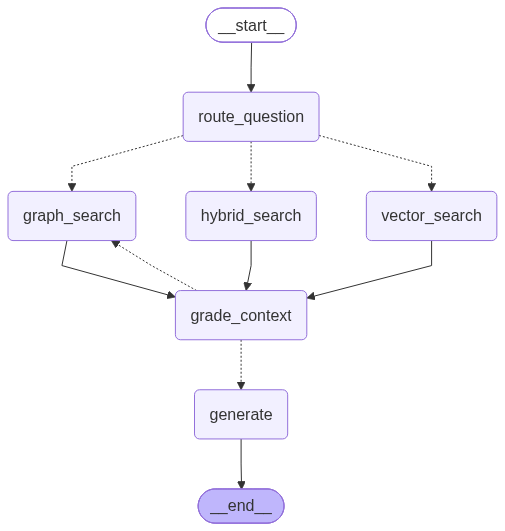

In [11]:
builder = StateGraph(RetrievalState)

builder.add_node("route_question", route_question)
builder.add_node("vector_search", vector_search)
builder.add_node("hybrid_search", hybrid_search)
builder.add_node("graph_search", graph_search)
builder.add_node("grade_context", grade_context)
builder.add_node("generate", generate)

builder.add_edge(START, "route_question")
builder.add_conditional_edges(
    "route_question",
    pick_retriever,
    ["vector_search", "hybrid_search", "graph_search"],
)

# Every retriever feeds the same grading node, which cannot be skipped.
for node in ["vector_search", "hybrid_search", "graph_search"]:
    builder.add_edge(node, "grade_context")

builder.add_conditional_edges("grade_context", decide_next, ["graph_search", "generate"])

builder.add_edge("generate", END)

retrieval_graph = builder.compile()

display(Image(retrieval_graph.get_graph(xray=True).draw_mermaid_png()))

Let's test it!

An analytical question should route straight to the graph retriever, which brings back relationships
and citations along with the text.

In [13]:
result = await retrieval_graph.ainvoke(
    {"question": "Which companies are expanding in AI space, and who competes with them?"}
)
print("\n" + result["answer"])

[route] theme
[retrieve] vector
[grade] sufficient=False - The context lists some AI-related companies, but it does not identify which companies are expanding in AI space or who their competitors are.
[route] insufficient - falling back to graph search
[retrieve] hybrid + graph traversal
[grade] sufficient=False - The context names some AI-focused companies and competitors, but it does not clearly identify which companies are expanding in AI space or fully answer who competes with them.

The context shows these companies expanding or advancing in the AI space:

- **H2O.ai** and **Hypergiant** — highlighted as AI innovators in *“Design The Next Stages Of Your Business With These Top Technology And AI Innovators”* (**2021-10-08**). Their listed competitors are **SAS**, **DataRobot**, **Abacus.AI**, **Amazon SageMaker**, and **Azure Cognitive Services**.
- **Apple** — described as expanding its AI footprint by buying the most AI companies in *“Apple Bought the Most AI Companies From 2016 

A broad thematic question takes the plain vector route - cheaper, and enough for the job.

In [14]:
result = await retrieval_graph.ainvoke(
    {"question": "What are the recent trends in data centers?"}
)
print("\n" + result["answer"])

[route] theme
[retrieve] vector
[grade] sufficient=True - The context describes recent data center trends such as virtualization, automation, blade servers, consolidation, cloud/hyperscale growth, and energy efficiency improvements.

The context suggests these recent data center trends:

- **Virtualization and automation** are helping data centers trim down and run faster.
- **Fewer, more powerful machines** are replacing larger numbers of smaller ones.
- **Data centers are becoming denser and hotter** as utilization increases.
- **Blade servers** are growing in prevalence as a more condensed form factor.
- **More powerful applications** and real-time data access needs are driving demand for faster processing.
- **Automation of hardware and software** is becoming important to control costs.
- **Compliance and disaster recovery** remain major concerns, pushing investment in always-available systems.
- In more recent context, **energy efficiency and sustainability** are key trends: lower

And a question about a specific named company goes through hybrid search, where full-text matching
catches the exact name that pure semantic similarity tends to miss.

In [15]:
result = await retrieval_graph.ainvoke(
    {"question": "What is being reported about Nvidia data center GPU demand?"}
)
print("\n" + result["answer"])

[route] analytical
[retrieve] hybrid + graph traversal
[grade] sufficient=True - The context says Nvidia’s data center GPU demand is unsatiated, especially for its latest H100 GPU, driving stronger revenue growth forecasts.

The context reports that demand for Nvidia’s data center GPUs is strong and “unsatiated,” especially for its latest H100 GPU. Morningstar said Nvidia’s data center segment revenue forecast was raised to 30% compound annual growth over the next five years, and that the uplift is “primarily driven by unsatiated demand for Nvidia’s latest H100 data center GPU” in **“5 Undervalued Semiconductor Stocks” (2023-06-01)**.


---

## Summary

In this notebook, we built a routed retrieval graph using `neo4j-graphrag` with LangGraph:

1. **Index pairing** - matched the embedding model to the vector index built with it, and confirmed it by re-embedding a stored chunk
2. **Three retrievers** - vector for themes, hybrid for named entities, and hybrid-plus-traversal for analytical questions that need relationships and citations
3. **Explicit routing** - a classification node and a conditional edge choose the retriever, rather than the model selecting a tool
4. **Unconditional grading** - a node judges the retrieved context on every question, with a bounded fallback to the broadest retriever

The retrievers are plain Python objects, so swapping one for another changes retrieval behaviour
without touching the graph around it. And because the routing and grading are edges rather than
prompt instructions, they run the same way every time.

In [16]:
driver.close()